## Indicate Dynawo and Modelica package.mo

In [ ]:
#=  The env variable DYNAWO_PATH must has be set beforehands to the root of the dynawo code.
    In case you are only working with the library distribution, the second part of the expression must be slightly modified.
    Anyway the package_file should be pointing to the package.mo file of the Dynawo library you want to use
=#

# Ruta de la librería Dynawo
ENV["DYNAWO_PATH"] = "/.../dynawo/sources/Models/Modelica/Dynawo"
Dynawo_package_file = string(ENV["DYNAWO_PATH"], "/package.mo")

# Ruta de la librería Modelica (ajusta según tu instalación)
ENV["MODELICA_PATH"] = "/.../dynawo/OpenModelica/lib/omlibrary/Modelica"
Modelica_package_file = string(ENV["MODELICA_PATH"], "/package.mo")


## Import packages and data

In [2]:
using OMJulia
using Plots, DataFrames, CSV

In [ ]:
# Load the dynamic model
BESS = OMJulia.OMCSession()
ModelicaSystem(BESS,Dynawo_package_file,"Dynawo.Examples.BESS.WECC.MyBESS",[Modelica_package_file])

# Load the auxiliary static model
StaticBESS = OMJulia.OMCSession()
ModelicaSystem(StaticBESS,Dynawo_package_file,"Dynawo.Examples.BESS.WECC.MyBESS_static",[Modelica_package_file])

## Run initial simulation

We are using the model Dynawo.Examples.BESS.WECC.BESScbCurrentSource from the v1.7.0 Dynawo Modelica library. This model has been initialized elsewhere and already includes the right initialization parameters. The BESS.INIT model is not explicitly used in the model, contrary to what happens in Dynawo.Examples.BESS.WECC.BESSCurrentSource from Dynawo's master release.

We check that we can load the model, run a simulation with OMJulia and plot some results.

WebIO._IJuliaInit()

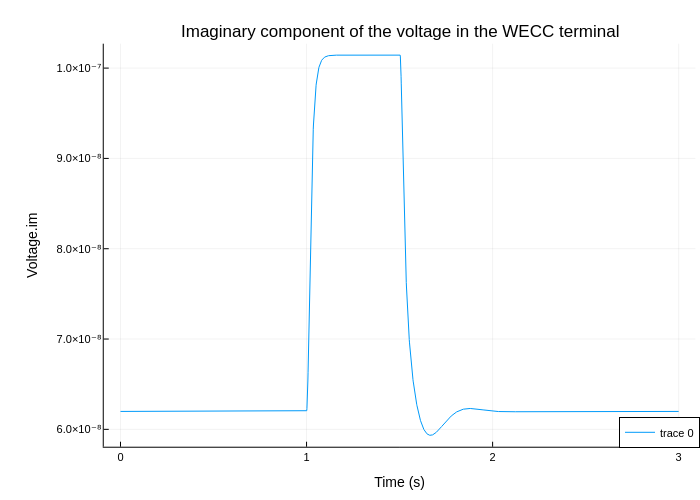

In [4]:
# Run the simulation of the dynamic model
resultfile_name = string("BESS_base", ".csv")
simulate(BESS,resultfile = resultfile_name,
                simflags = "-override=outputFormat=csv")
resultfile = joinpath(getWorkDirectory(BESS), resultfile_name)
df = DataFrame(CSV.File(resultfile));

# Plot the imaginary component of the voltage in the WECC terminal
plotlyjs()
p2 = plot(df[!, "time"], df[!, "BESS.terminal.V.im"], label=["Terminal V.im"])
plot!(p2, legend=:bottomright, titlefontsize=12, labelfontsize=10)
title!(p2, "Imaginary component of the voltage in the WECC terminal")
xlabel!(p2, "Time (s)")
ylabel!(p2, "Voltage.im")  

## Initialization with a static model

We want to automatise the initialization by using an auxiliary model that solves an initial power flow and also runs the INIT model por the internal BESS parameters.

In the static model (Dynawo.Examples.BESS.WECC.StaticBESS), we replace the BESS WECC by a simplified generator with fixed PV and remove the fault in the infinite bus. We also include the BESS_INIT and the initial algorithm.

The initial power flow allows us to initialize the BESS_INIT model, which requires the initial values of complex voltage and complex power.

The procedure is the following: first we simulate the static model, which runs the BESS_INIT and gives us a series of variables as a result. After that, we extract the variables and set them as initial parameters for the BESS in the dynamic model.

In [5]:
# Run the simulation of the auxiliary static model
simulate(StaticBESS)

# Extract the model continuous variables
(Id0Pu, Iq0Pu, PF0, PInj0Pu, QInj0Pu, UInj0Pu, i0Pu_re, i0Pu_im, iInj0Pu_re, iInj0Pu_im, u0Pu_re, u0Pu_im, uInj0Pu_re, uInj0Pu_im) = getContinuous(StaticBESS, ["bess_INIT.Id0Pu","bess_INIT.Iq0Pu","bess_INIT.PF0","bess_INIT.PInj0Pu","bess_INIT.QInj0Pu","bess_INIT.UInj0Pu","bess_INIT.i0Pu.re","bess_INIT.i0Pu.im","bess_INIT.iInj0Pu.re","bess_INIT.iInj0Pu.im","bess_INIT.u0Pu.re","bess_INIT.u0Pu.im","bess_INIT.uInj0Pu.re","bess_INIT.uInj0Pu.im"]);

# Extract the values of the parameter s0Pu
wd  = getWorkDirectory(StaticBESS)
exe = joinpath(wd, "Dynawo.Examples.BESS.WECC.MyBESS_static")
out = read(Cmd(`$exe -output=bess_INIT.s0Pu.re,bess_INIT.s0Pu.im`; dir=wd), String)
mre = match(r"bess_INIT\.s0Pu\.re=([-\d\.eE\+]+)", out)
mim = match(r"bess_INIT\.s0Pu\.im=([-\d\.eE\+]+)", out)
s0_re = parse(Float64, mre.captures[1])
s0_im = parse(Float64, mim.captures[1]);

In [6]:
# Set the initial values of the parameters of the dynamic model
setParameters(BESS, [
    "BESS.Id0Pu = " * string(Id0Pu),
    "BESS.Iq0Pu = " * string(Iq0Pu),
    "BESS.PF0 = " * string(PF0),
    "BESS.PInj0Pu = " * string(PInj0Pu),
    "BESS.QInj0Pu = " * string(QInj0Pu),
    "BESS.UInj0Pu = " * string(UInj0Pu),
    "BESS.i0Pu.re = " * string(i0Pu_re),
    "BESS.i0Pu.im = " * string(i0Pu_im),
    "BESS.iInj0Pu.re = " * string(iInj0Pu_re),
    "BESS.iInj0Pu.im = " * string(iInj0Pu_im),
    "BESS.u0Pu.re = " * string(u0Pu_re),
    "BESS.u0Pu.im = " * string(u0Pu_im),
    "BESS.uInj0Pu.re = " * string(uInj0Pu_re),
    "BESS.uInj0Pu.im = " * string(uInj0Pu_im),
    "BESS.s0Pu.re = " * string(s0_re),
    "BESS.s0Pu.im = " * string(s0_im),
])

BESS.uInj0Pu.im=-6.197999999999998e-8

BESS.Id0Pu=0.5

BESS.s0Pu.im=9.997267555296222e-10

BESS.UInj0Pu=1.0

BESS.s0Pu.re=-0.03

BESS.uInj0Pu.re=0.9999999999999981

BESS.iInj0Pu.im=-1.432938740783965e-8

BESS.i0Pu.im=8.59763244470379e-10

BESS.Iq0Pu=-1.666061259216037e-8

BESS.u0Pu.im=-6.198299999999998e-8

BESS.PInj0Pu=0.5

BESS.QInj0Pu=-1.666061259216037e-8

BESS.u0Pu.re=0.9999999999999981

BESS.i0Pu.re=-0.030000000000000006

BESS.PF0=0.9999999999999996

BESS.iInj0Pu.re=0.5000000000000001



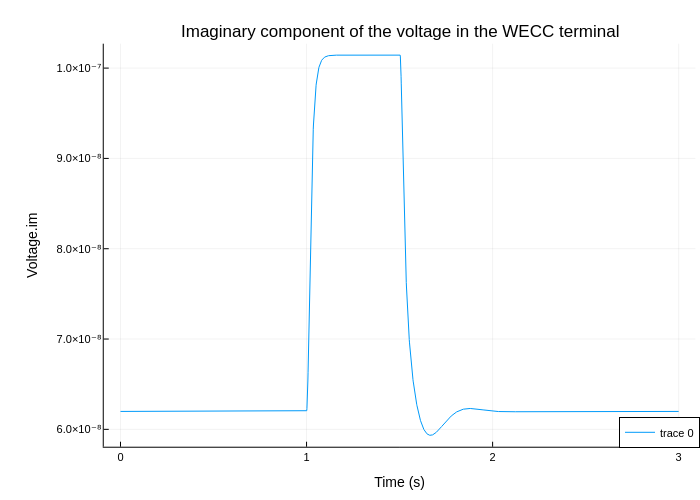

In [7]:
# Run the simulation of the dynamic model
resultfile_name = string("BESS_modified", ".csv")
simulate(BESS,resultfile = resultfile_name,
                simflags = "-override=outputFormat=csv")
resultfile = joinpath(getWorkDirectory(BESS), resultfile_name)
df = DataFrame(CSV.File(resultfile));

# Plot the imaginary component of the voltage in the WECC terminal
plotlyjs()
p2 = plot(df[!, "time"], df[!, "BESS.terminal.V.im"], label=["Terminal V.im"])
plot!(p2, legend=:bottomright, titlefontsize=12, labelfontsize=10)
title!(p2, "Imaginary component of the voltage in the WECC terminal")
xlabel!(p2, "Time (s)")
ylabel!(p2, "Voltage.im")  

## Modification of the BESS resistance RPu

We can change some of the model parameters, such as the internal resistance of the BESS (RPu). Running the same dynamic simulation as before, we observe some irregular behavior around the initial time. This is because the initial parameter values set by hand in the model are no longer adequate.

In [ ]:
# Load the dynamic model
BESS = OMJulia.OMCSession()
ModelicaSystem(BESS,Dynawo_package_file,"Dynawo.Examples.BESS.WECC.MyBESS",[Modelica_package_file])

# Modify the BESS resistance RPu
setParameters(BESS, ["BESS.RPu = " * "0.5"])
buildModel(BESS)

BESS.RPu=0.5



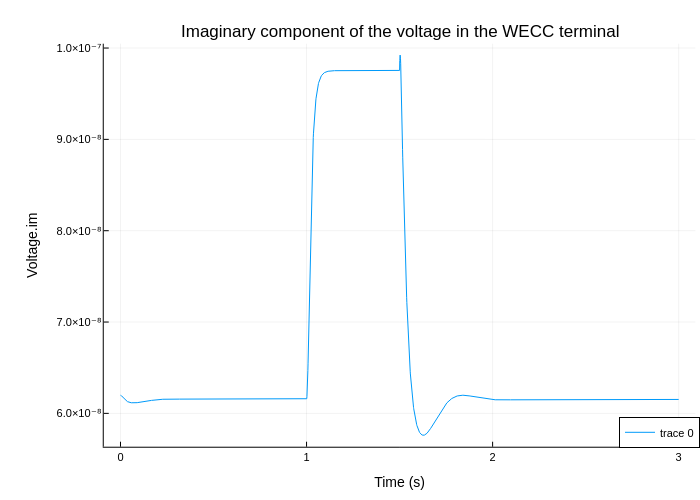

In [9]:
# Run the simulation of the dynamic model
resultfile_name = string("BESS_XPu", ".csv")
simulate(BESS,
         resultfile = resultfile_name,
         simflags = "-override=outputFormat=csv")
resultfile = joinpath(getWorkDirectory(BESS), resultfile_name)
df = DataFrame(CSV.File(resultfile));

# Plot the imaginary component of the voltage in the WECC terminal
plotlyjs()
p2 = plot(df[!, "time"], df[!, "BESS.terminal.V.im"], label=["Terminal V.im"])
plot!(p2, legend=:bottomright, titlefontsize=12, labelfontsize=10)
title!(p2, "Imaginary component of the voltage in the WECC terminal")
xlabel!(p2, "Time (s)")
ylabel!(p2, "Voltage.im")  

## Initialization with the modified BESS resistance

If instead we initialise the model by using the auxiliary static model, the new initial parameter values are calculated automatically, and the final simulation does not exhibit irregular initial behavior.

In [ ]:
# Load the auxiliary static model
StaticBESS = OMJulia.OMCSession()
ModelicaSystem(StaticBESS,Dynawo_package_file,"Dynawo.Examples.BESS.WECC.MyBESS_static",[Modelica_package_file])

# Modify the BESS_INIT resistance RPu
setParameters(StaticBESS, ["bess_INIT.RPu = " * "0.5"])
buildModel(StaticBESS)

In [11]:
# Run the simulation of the auxiliary static model
simulate(StaticBESS);

# Extract the model continuous variables
(Id0Pu, Iq0Pu, PF0, PInj0Pu, QInj0Pu, UInj0Pu, i0Pu_re, i0Pu_im, iInj0Pu_re, iInj0Pu_im, u0Pu_re, u0Pu_im, uInj0Pu_re, uInj0Pu_im) = getContinuous(StaticBESS, ["bess_INIT.Id0Pu","bess_INIT.Iq0Pu","bess_INIT.PF0","bess_INIT.PInj0Pu","bess_INIT.QInj0Pu","bess_INIT.UInj0Pu","bess_INIT.i0Pu.re","bess_INIT.i0Pu.im","bess_INIT.iInj0Pu.re","bess_INIT.iInj0Pu.im","bess_INIT.u0Pu.re","bess_INIT.u0Pu.im","bess_INIT.uInj0Pu.re","bess_INIT.uInj0Pu.im"]);

# Extract the values of the parameter s0Pu
wd  = getWorkDirectory(StaticBESS)
exe = joinpath(wd, "Dynawo.Examples.BESS.WECC.MyBESS_static")
out = read(Cmd(`$exe -output=bess_INIT.s0Pu.re,bess_INIT.s0Pu.im`; dir=wd), String)
mre = match(r"bess_INIT\.s0Pu\.re=([-\d\.eE\+]+)", out)
mim = match(r"bess_INIT\.s0Pu\.im=([-\d\.eE\+]+)", out)
s0_re = parse(Float64, mre.captures[1])
s0_im = parse(Float64, mim.captures[1]);

bess_INIT.RPu=0.5



In [12]:
# Set the initial values of the parameters of the dynamic model
setParameters(BESS, [
    "BESS.Id0Pu = " * string(Id0Pu),
    "BESS.Iq0Pu = " * string(Iq0Pu),
    "BESS.PF0 = " * string(PF0),
    "BESS.PInj0Pu = " * string(PInj0Pu),
    "BESS.QInj0Pu = " * string(QInj0Pu),
    "BESS.UInj0Pu = " * string(UInj0Pu),
    "BESS.i0Pu.re = " * string(i0Pu_re),
    "BESS.i0Pu.im = " * string(i0Pu_im),
    "BESS.iInj0Pu.re = " * string(iInj0Pu_re),
    "BESS.iInj0Pu.im = " * string(iInj0Pu_im),
    "BESS.u0Pu.re = " * string(u0Pu_re),
    "BESS.u0Pu.im = " * string(u0Pu_im),
    "BESS.uInj0Pu.re = " * string(uInj0Pu_re),
    "BESS.uInj0Pu.im = " * string(uInj0Pu_im),
    "BESS.s0Pu.re = " * string(s0_re),
    "BESS.s0Pu.im = " * string(s0_im),
])

BESS.uInj0Pu.im=-6.240988162223516e-8

BESS.Id0Pu=0.5

BESS.s0Pu.im=9.997267555296222e-10

BESS.UInj0Pu=1.0150000000000001

BESS.s0Pu.re=-0.03

BESS.uInj0Pu.re=1.0149999999999981

BESS.iInj0Pu.im=-1.432938740783965e-8

BESS.RPu=0.5

BESS.i0Pu.im=8.59763244470379e-10

BESS.Iq0Pu=-1.641439664252253e-8

BESS.u0Pu.im=-6.198299999999998e-8

BESS.PInj0Pu=0.5075000000000001

BESS.QInj0Pu=-1.666061259216037e-8

BESS.u0Pu.re=0.9999999999999981

BESS.i0Pu.re=-0.030000000000000006

BESS.PF0=0.9999999999999996

BESS.iInj0Pu.re=0.5000000000000001



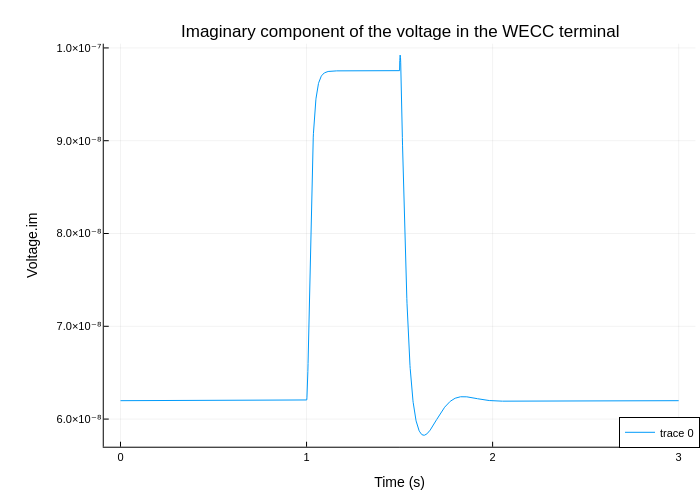

In [13]:
# Modify the BESS resistance RPu
setParameters(BESS, ["BESS.RPu = " * "0.5"])
buildModel(BESS)

# Run the simulation of the dynamic model
resultfile_name = string("BESS_XPu", ".csv")
simulate(BESS,
         resultfile = resultfile_name,
         simflags = "-override=outputFormat=csv")
resultfile = joinpath(getWorkDirectory(BESS), resultfile_name)
df = DataFrame(CSV.File(resultfile));

# Plot the imaginary component of the voltage in the WECC terminal
plotlyjs()
p2 = plot(df[!, "time"], df[!, "BESS.terminal.V.im"], label=["Terminal V.im"])
plot!(p2, legend=:bottomright, titlefontsize=12, labelfontsize=10)
title!(p2, "Imaginary component of the voltage in the WECC terminal")
xlabel!(p2, "Time (s)")
ylabel!(p2, "Voltage.im")  